In [105]:
import pandas as pd
df = pd.read_csv("arrhythmia.csv", header=None, na_values="?")

In [106]:
print(df.shape)

print(df.head())


(452, 280)
   0    1    2    3    4    5    6    7    8    9    ...  270   271  272  273  \
0   75    0  190   80   91  193  371  174  121  -16  ...  0.0   9.0 -0.9  0.0   
1   56    1  165   64   81  174  401  149   39   25  ...  0.0   8.5  0.0  0.0   
2   54    0  172   95  138  163  386  185  102   96  ...  0.0   9.5 -2.4  0.0   
3   55    0  175   94  100  202  380  179  143   28  ...  0.0  12.2 -2.2  0.0   
4   75    0  190   80   88  181  360  177  103  -16  ...  0.0  13.1 -3.6  0.0   

   274  275  276   277   278  279  
0  0.0  0.9  2.9  23.3  49.4    8  
1  0.0  0.2  2.1  20.4  38.8    6  
2  0.0  0.3  3.4  12.3  49.0   10  
3  0.0  0.4  2.6  34.6  61.6    1  
4  0.0 -0.1  3.9  25.4  62.8    7  

[5 rows x 280 columns]


In [107]:
df.columns = ["age","sex","height","weight","qrs_duration","pr_interval",
              "qt_interval","t_interval","p_interval","qrs_angle","t_angle",
              "p_angle","qrst_angle","j_angle","heart_rate"] \
             + list(df.columns[15:-1]) + ["class"]

print(df.columns[-3:])

print(df.head())


Index([277, 278, 'class'], dtype='object')
   age  sex  height  weight  qrs_duration  pr_interval  qt_interval  \
0   75    0     190      80            91          193          371   
1   56    1     165      64            81          174          401   
2   54    0     172      95           138          163          386   
3   55    0     175      94           100          202          380   
4   75    0     190      80            88          181          360   

   t_interval  p_interval  qrs_angle  ...  270   271  272  273  274  275  276  \
0         174         121        -16  ...  0.0   9.0 -0.9  0.0  0.0  0.9  2.9   
1         149          39         25  ...  0.0   8.5  0.0  0.0  0.0  0.2  2.1   
2         185         102         96  ...  0.0   9.5 -2.4  0.0  0.0  0.3  3.4   
3         179         143         28  ...  0.0  12.2 -2.2  0.0  0.0  0.4  2.6   
4         177         103        -16  ...  0.0  13.1 -3.6  0.0  0.0 -0.1  3.9   

    277   278  class  
0  23.3  49.4      8

In [108]:
import pandas as pd
import sqlite3

# Keep an untouched copy of the loaded and named dataset
df_original = df.copy(deep=True)


In [109]:
# Check missing values
missing = df_original.isna().sum()
print("Columns containing missing values:")
print(missing[missing > 0].sort_values(ascending=False))

# Check duplicate rows
print("\nNumber of duplicate rows:")
print(df_original.duplicated().sum())

# Check the ranges of important measurements
range_cols = ["age", "height", "weight", "heart_rate"]

print("\nMinimum and maximum values:")
print(df_original[range_cols].agg(["min", "max"]))


Columns containing missing values:
j_angle       376
p_angle        22
t_angle         8
qrst_angle      1
heart_rate      1
dtype: int64

Number of duplicate rows:
0

Minimum and maximum values:
     age  height  weight  heart_rate
min    0     105       6        44.0
max   83     780     176       163.0


In [110]:
review_cols = [
    "age",
    "sex",
    "height",
    "weight",
    "class"
]

records_to_review = df_original.loc[
    (df_original["age"] < 18) |
    (df_original["height"] < 120) |
    (df_original["height"] > 220) |
    (df_original["weight"] < 25),
    review_cols
].sort_values(
    ["age", "height", "weight"]
)

print(records_to_review.to_string())


     age  sex  height  weight  class
316    0    0     608      10      5
60     1    0     110      10      5
141    1    1     780       6      5
320    3    0     105      12      5
424    7    0     119      21      9
403    7    1     127      22      5
297    7    1     130      30     10
379    8    0     120      28     10
429    8    1     130      24     16
401    9    0     120      25     14
113    9    0     132      33      1
210   11    1     124      25     10
430   11    0     138      29     10
432   11    0     140      42     10
298   12    1     165      47     10
198   13    1     133      30     16
5     13    0     169      51     14
305   14    0     175      59      1
374   15    1     163      38      5
250   15    1     170      53     10
393   16    1     160      60      1
216   17    1     156      40      2
149   17    1     160      54     10
108   17    0     170      61      2
126   58    0     186      18      1


In [111]:
records_to_review = records_to_review.copy()

records_to_review["bmi"] = (
    records_to_review["weight"] /
    (records_to_review["height"] / 100) ** 2
)

print(records_to_review.round(2).to_string())


     age  sex  height  weight  class    bmi
316    0    0     608      10      5   0.27
60     1    0     110      10      5   8.26
141    1    1     780       6      5   0.10
320    3    0     105      12      5  10.88
424    7    0     119      21      9  14.83
403    7    1     127      22      5  13.64
297    7    1     130      30     10  17.75
379    8    0     120      28     10  19.44
429    8    1     130      24     16  14.20
401    9    0     120      25     14  17.36
113    9    0     132      33      1  18.94
210   11    1     124      25     10  16.26
430   11    0     138      29     10  15.23
432   11    0     140      42     10  21.43
298   12    1     165      47     10  17.26
198   13    1     133      30     16  16.96
5     13    0     169      51     14  17.86
305   14    0     175      59      1  19.27
374   15    1     163      38      5  14.30
250   15    1     170      53     10  18.34
393   16    1     160      60      1  23.44
216   17    1     156      40   

In [112]:
def clean_data(data):
    # Work on a copy so the supplied DataFrame is not changed
    clean = data.copy(deep=True)

    # Standardise sex labels if letter labels are present
    clean["sex"] = clean["sex"].replace({
        "M": 0,
        "F": 1,
        "m": 0,
        "f": 1
    })

    # Calculate BMI to check whether height and weight
    # are internally consistent
    clean["bmi"] = (
        clean["weight"] /
        (clean["height"] / 100) ** 2
    )

    # Identify clearly unreliable demographic records
    invalid_record = (
        # A height above 250 cm is physically implausible
        (clean["height"] > 250)

        # A recorded height above 100 cm for age 0 or 1
        # is highly inconsistent with the recorded age
        | (
            (clean["age"] <= 1) &
            (clean["height"] > 100)
        )

        # An adult BMI below 10 suggests that the recorded
        # height and weight are internally inconsistent
        | (
            (clean["age"] >= 20) &
            (clean["bmi"] < 10)
        )
    )

    # Display the records before removing them
    print("Clearly unreliable records removed during cleaning:")

    print(
        clean.loc[
            invalid_record,
            [
                "age",
                "sex",
                "height",
                "weight",
                "bmi",
                "class"
            ]
        ].round(2)
    )

    # Remove the clearly unreliable records
    clean = clean.loc[~invalid_record].copy()

    # Recalculate BMI for the retained records
    clean["bmi"] = (
        clean["weight"] /
        (clean["height"] / 100) ** 2
    )

    # Fill ECG columns containing only a small
    # number of missing values
    for col in [
        "p_angle",
        "t_angle",
        "qrst_angle",
        "heart_rate"
    ]:
        clean[col] = clean[col].fillna(
            clean[col].median()
        )

    # Drop j_angle because most of its values are missing
    clean = clean.drop(
        columns=["j_angle"],
        errors="ignore"
    )

    # Remove exact duplicate rows
    clean = clean.drop_duplicates()

    # Create a simpler yes/no diagnosis column
    clean["arrhythmia_present"] = (
        clean["class"] != 1
    )

    # Reset the row numbers after records are removed
    clean = clean.reset_index(drop=True)

    return clean


In [113]:
# Apply the cleaning function to the original data
df_clean_preview = clean_data(df_original)


Clearly unreliable records removed during cleaning:
     age  sex  height  weight   bmi  class
60     1    0     110      10  8.26      5
126   58    0     186      18  5.20      1
141    1    1     780       6  0.10      5
316    0    0     608      10  0.27      5


In [114]:
print("Original shape:", df_original.shape)
print("Cleaned shape:", df_clean_preview.shape)

print(
    "Rows removed:",
    len(df_original) - len(df_clean_preview)
)


Original shape: (452, 280)
Cleaned shape: (448, 281)
Rows removed: 4


In [115]:
demographic_cols = [
    "age",
    "height",
    "weight",
    "bmi"
]

print("\nCleaned demographic ranges:")

print(df_clean_preview[demographic_cols]
    .agg(["min", "max"])
)




Cleaned demographic ranges:
     age  height  weight        bmi
min    3     105      12  10.884354
max   83     190     176  61.622492


In [116]:
print(
    "\nHeights above 250 cm:",
    (df_clean_preview["height"] > 250).sum()
)

print(
    "Infant records with height above 100 cm:",
    (
        (df_clean_preview["age"] <= 1) &
        (df_clean_preview["height"] > 100)
    ).sum()
)

print(
    "Adults with BMI below 10:",
    (
        (df_clean_preview["age"] >= 20) &
        (df_clean_preview["bmi"] < 10)
    ).sum()
)
demographic_cols = [
    "age",
    "height",
    "weight",
    "bmi"
]

print("\nCleaned demographic ranges:")

print(
    df_clean_preview[demographic_cols]
    .agg(["min", "max"])
)



Heights above 250 cm: 0
Infant records with height above 100 cm: 0
Adults with BMI below 10: 0

Cleaned demographic ranges:
     age  height  weight        bmi
min    3     105      12  10.884354
max   83     190     176  61.622492


In [117]:
missing = df_clean_preview.isna().sum()

print("\nColumns still containing missing values:")

print(
    missing[missing > 0]
    .sort_values(ascending=False)
)

print(
    "\nDuplicate rows:",
    df_clean_preview.duplicated().sum()
)



Columns still containing missing values:
Series([], dtype: int64)

Duplicate rows: 0


In [118]:
print(
    "\nj_angle still present:",
    "j_angle" in df_clean_preview.columns
)

print(
    "BMI column present:",
    "bmi" in df_clean_preview.columns
)

print(
    "arrhythmia_present column present:",
    "arrhythmia_present" in df_clean_preview.columns
)



j_angle still present: False
BMI column present: True
arrhythmia_present column present: True


In [119]:
print("\nFirst five cleaned records:")

print(
    df_clean_preview[
        [
            "age",
            "sex",
            "height",
            "weight",
            "bmi",
            "heart_rate",
            "class",
            "arrhythmia_present"
        ]
    ].head()
) 



First five cleaned records:
   age  sex  height  weight        bmi  heart_rate  class  arrhythmia_present
0   75    0     190      80  22.160665        63.0      8                True
1   56    1     165      64  23.507805        53.0      6                True
2   54    0     172      95  32.111952        75.0     10                True
3   55    0     175      94  30.693878        71.0      1               False
4   75    0     190      80  22.160665        72.0      7                True


In [120]:
import sqlite3

In [121]:
# Use the cleaned data already reviewed in Section 2.9
df_etl_clean = df_clean_preview.copy(deep=True)

with sqlite3.connect("etl.db") as conn:
    df_etl_clean.to_sql(
        "clean",
        conn,
        if_exists="replace",
        index=False
    )

print("ETL completed.")
print("Cleaned table shape:", df_etl_clean.shape)

ETL completed.
Cleaned table shape: (448, 281)


In [122]:
with sqlite3.connect("elt.db") as conn:

    # Load the untouched raw data first
    df_original.to_sql(
        "raw",
        conn,
        if_exists="replace",
        index=False
    )

    # Read the raw table back into Pandas
    df_elt_raw = pd.read_sql(
        "SELECT * FROM raw",
        conn
    )

    # Transform the data after loading
    df_elt_clean = clean_data(df_elt_raw)

    # Store the cleaned result as a second table
    df_elt_clean.to_sql(
        "clean",
        conn,
        if_exists="replace",
        index=False
    )

print("ELT completed.")
print("Raw table shape:", df_elt_raw.shape)
print("Cleaned table shape:", df_elt_clean.shape)

Clearly unreliable records removed during cleaning:
     age  sex  height  weight   bmi  class
60     1    0     110      10  8.26      5
126   58    0     186      18  5.20      1
141    1    1     780       6  0.10      5
316    0    0     608      10  0.27      5
ELT completed.
Raw table shape: (452, 280)
Cleaned table shape: (448, 281)


In [123]:
with sqlite3.connect("etl.db") as conn:
    etl_tables = pd.read_sql(
        "SELECT name FROM sqlite_master WHERE type='table'",
        conn
    )

print("Tables in etl.db:")
print(etl_tables)


with sqlite3.connect("elt.db") as conn:
    elt_tables = pd.read_sql(
        "SELECT name FROM sqlite_master WHERE type='table'",
        conn
    )

print("\nTables in elt.db:")
print(elt_tables)


Tables in etl.db:
    name
0  clean

Tables in elt.db:
    name
0    raw
1  clean


In [124]:
print(df_original["heart_rate"].mean())          # one number, a Series method

print(df_original[["heart_rate", "age"]].mean())    # one number PER column, a DataFrame method


74.46341463414635
heart_rate    74.463415
age           46.471239
dtype: float64


In [125]:
import time
# Slow method: loop
start = time.time()
slow_result = []
for i in range(len(df_original)):
    slow_result.append(
df_original["weight"].iloc[i] / df_original["height"].iloc[i]
    )
slow_time = time.time() - start
# Fast method: vectorised calculation
start = time.time()
fast_result = df_original["weight"] / df_original["height"]
fast_time = time.time() - start
# Compare the first five results
print("Slow result:")
print(slow_result[:5])
print("\nFast result:")
print(fast_result.head().tolist())
# Compare the speed
print("\nSlow time:", slow_time)
print("Fast time:", fast_time)
print("\nFast method is", slow_time / fast_time, "times faster")


Slow result:
[np.float64(0.42105263157894735), np.float64(0.3878787878787879), np.float64(0.5523255813953488), np.float64(0.5371428571428571), np.float64(0.42105263157894735)]

Fast result:
[0.42105263157894735, 0.3878787878787879, 0.5523255813953488, 0.5371428571428571, 0.42105263157894735]

Slow time: 0.011300086975097656
Fast time: 0.000324249267578125

Fast method is 34.85 times faster


In [126]:
print(df_original.shape)

print(df_original.dtypes.value_counts())

print(df_original.info())

print(df_original.describe())


(452, 280)
int64      155
float64    125
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Columns: 280 entries, age to class
dtypes: float64(125), int64(155)
memory usage: 988.9 KB
None
              age         sex      height      weight  qrs_duration  \
count  452.000000  452.000000  452.000000  452.000000    452.000000   
mean    46.471239    0.550885  166.188053   68.170354     88.920354   
std     16.466631    0.497955   37.170340   16.590803     15.364394   
min      0.000000    0.000000  105.000000    6.000000     55.000000   
25%     36.000000    0.000000  160.000000   59.000000     80.000000   
50%     47.000000    1.000000  164.000000   68.000000     86.000000   
75%     58.000000    1.000000  170.000000   79.000000     94.000000   
max     83.000000    1.000000  780.000000  176.000000    188.000000   

       pr_interval  qt_interval  t_interval  p_interval   qrs_angle  ...  \
count   452.000000   452.000000  452.000000  452.000000  452

In [127]:
summary_cols = ["age", "height", "weight", "heart_rate"]
print(df_etl_clean[summary_cols].describe())

skew_results = df_etl_clean[summary_cols].skew().round(2)
print(skew_results)

print(df_etl_clean["arrhythmia_present"].value_counts(normalize=True))

# Expected under the current rules: age and weight keep their raw minima.
print("Minimum age retained:", df_etl_clean["age"].min())
print("Minimum weight retained:", df_etl_clean["weight"].min())


              age      height      weight  heart_rate
count  448.000000  448.000000  448.000000  448.000000
mean    46.752232  163.912946   68.680804   74.062500
std     16.097125   10.065291   15.749248   12.844296
min      3.000000  105.000000   12.000000   44.000000
25%     36.000000  160.000000   59.750000   65.000000
50%     47.000000  164.000000   68.000000   72.000000
75%     58.250000  170.000000   79.000000   81.000000
max     83.000000  190.000000  176.000000  124.000000
age          -0.21
height       -1.24
weight        0.54
heart_rate    0.83
dtype: float64
arrhythmia_present
False    0.544643
True     0.455357
Name: proportion, dtype: float64
Minimum age retained: 3
Minimum weight retained: 12


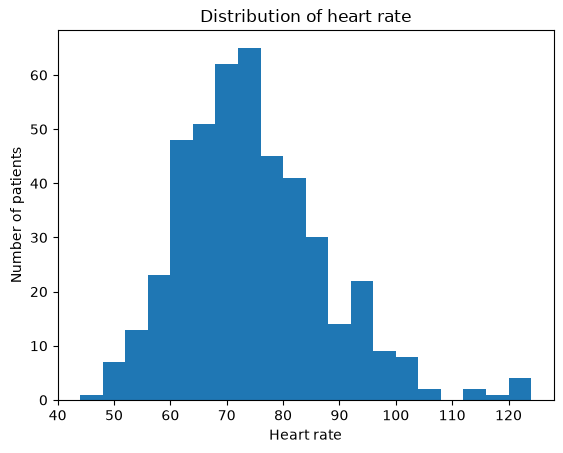

In [128]:
import matplotlib.pyplot as plt

plt.hist(df_etl_clean["heart_rate"].dropna(), bins=20)
plt.xlabel("Heart rate"); plt.ylabel("Number of patients")
plt.title("Distribution of heart rate")
plt.show() 


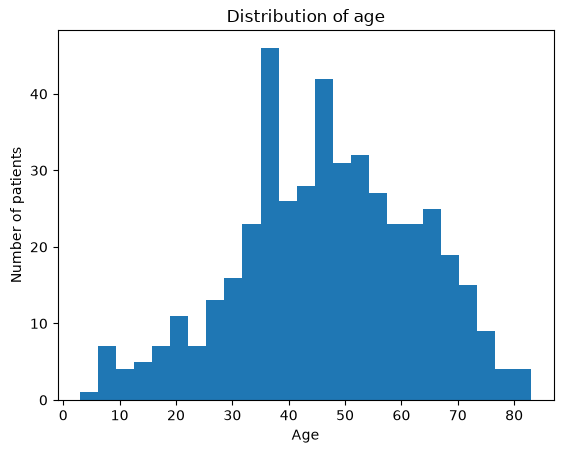

In [129]:
plt.hist(df_etl_clean["age"].dropna(), bins=25)
plt.xlabel("Age")
plt.ylabel("Number of patients")
plt.title("Distribution of age")
plt.show()


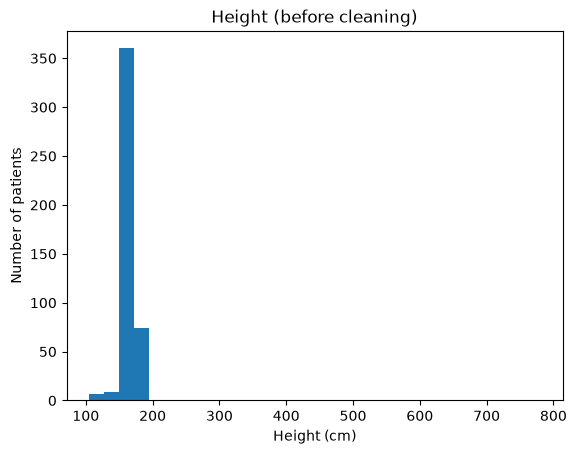

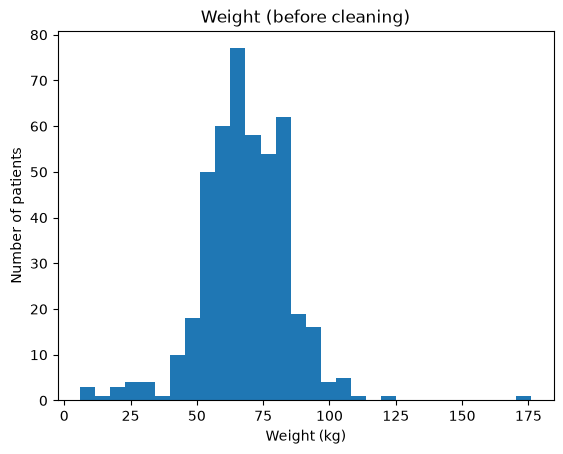

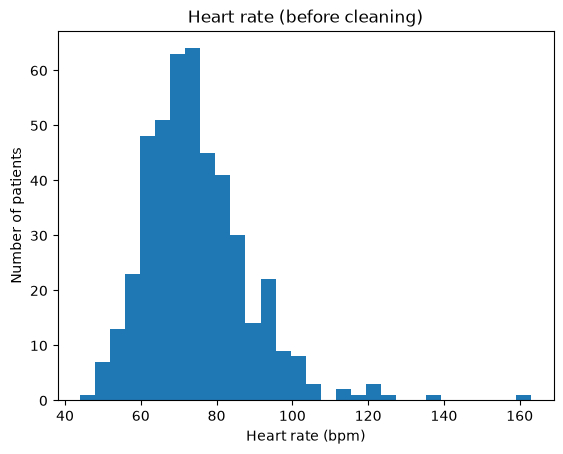

In [130]:
import matplotlib.pyplot as plt

plt.hist(df_original["height"].dropna(), bins=30)
plt.title("Height (before cleaning)")
plt.xlabel("Height (cm)")
plt.ylabel("Number of patients")
plt.show()

plt.hist(df_original["weight"].dropna(), bins=30)
plt.title("Weight (before cleaning)")
plt.xlabel("Weight (kg)")
plt.ylabel("Number of patients")
plt.show()

plt.hist(df_original["heart_rate"].dropna(), bins=30)
plt.title("Heart rate (before cleaning)")
plt.xlabel("Heart rate (bpm)")
plt.ylabel("Number of patients")
plt.show()


In [131]:
# Compare the variables that were reviewed during cleaning
for col in ["age", "height", "weight", "heart_rate"]:
    print(
        col,
        "raw range:",
        (df_original[col].min(), df_original[col].max()),
        "clean range:",
        (df_etl_clean[col].min(), df_etl_clean[col].max())
    )


age raw range: (np.int64(0), np.int64(83)) clean range: (np.int64(3), np.int64(83))
height raw range: (np.int64(105), np.int64(780)) clean range: (np.int64(105), np.int64(190))
weight raw range: (np.int64(6), np.int64(176)) clean range: (np.int64(12), np.int64(176))
heart_rate raw range: (np.float64(44.0), np.float64(163.0)) clean range: (np.float64(44.0), np.float64(124.0))


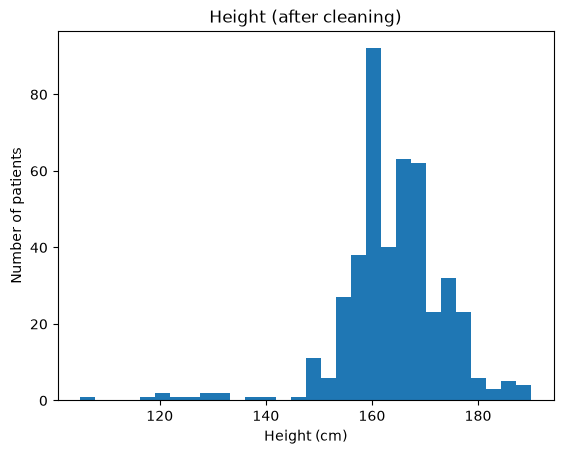

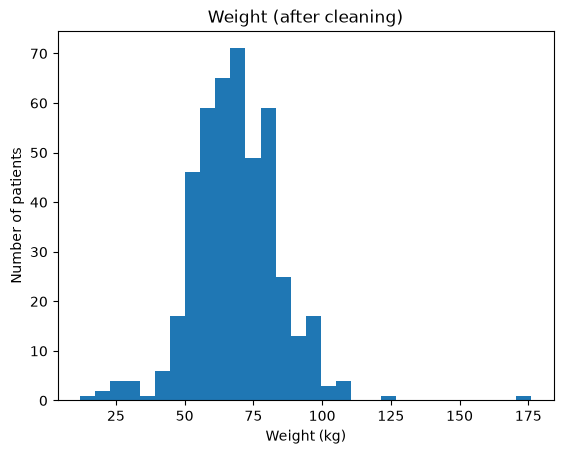

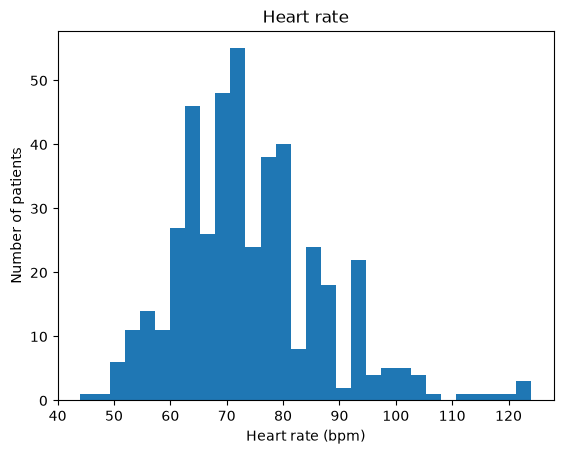

In [132]:
plt.hist(df_etl_clean["height"].dropna(), bins=30)
plt.title("Height (after cleaning)")
plt.xlabel("Height (cm)")
plt.ylabel("Number of patients")
plt.show()

plt.hist(df_etl_clean["weight"].dropna(), bins=30)
plt.title("Weight (after cleaning)")
plt.xlabel("Weight (kg)")
plt.ylabel("Number of patients")
plt.show()

plt.hist(df_etl_clean["heart_rate"].dropna(), bins=30)
plt.title("Heart rate")
plt.xlabel("Heart rate (bpm)")
plt.ylabel("Number of patients")
plt.show()


C:\Users\akalra\AppData\Local\Temp\ipykernel_29420\1113486248.py:1: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_etl_clean["weight"].dropna(), vert=False, tick_labels=["Weight"])


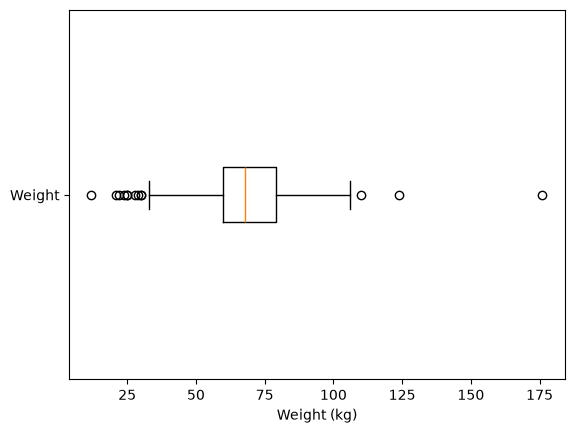

In [133]:
plt.boxplot(df_etl_clean["weight"].dropna(), vert=False, tick_labels=["Weight"])
plt.xlabel("Weight (kg)")
plt.show()          # Figure 10 is what you'll see


In [134]:

def iqr_flag(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)

age_flag = iqr_flag(df_etl_clean["age"])
height_flag = iqr_flag(df_etl_clean["height"])
weight_flag = iqr_flag(df_etl_clean["weight"])

demographic_flags = age_flag | height_flag | weight_flag
print(
    df_etl_clean.loc[
        demographic_flags,
        ["age", "sex", "height", "weight", "class"]
    ].sort_values(["age", "height", "weight"]).to_string()
)

# Heart rate is checked separately with a z-score
mean_hr = df_etl_clean["heart_rate"].mean()
std_hr = df_etl_clean["heart_rate"].std()
z_hr = (df_etl_clean["heart_rate"] - mean_hr) / std_hr
print("Heart-rate values with |z| > 3:")
print(df_etl_clean.loc[z_hr.abs() > 3, ["age", "sex", "heart_rate", "class"]])


     age  sex  height  weight  class
316    3    0     105      12      5
420    7    0     119      21      9
399    7    1     127      22      5
294    7    1     130      30     10
375    8    0     120      28     10
425    8    1     130      24     16
397    9    0     120      25     14
112    9    0     132      33      1
207   11    1     124      25     10
426   11    0     138      29     10
428   11    0     140      42     10
195   13    1     133      30     16
342   20    0     186      66     10
444   37    0     190      85     10
328   42    0     188      91     16
419   51    0     186      95      1
210   53    0     169     176      2
305   62    1     170     110      2
251   66    1     160     124      1
0     75    0     190      80      8
4     75    0     190      80      7
Heart-rate values with |z| > 3:
     age  sex  heart_rate  class
240   49    1       115.0     15
316    3    0       124.0      5
375    8    0       123.0     10
383   53    1       11

In [135]:
print(
    df_etl_clean.loc[
        (df_etl_clean["age"] == 75) &
        (df_etl_clean["sex"] == 0) &
        (df_etl_clean["height"] == 190) &
        (df_etl_clean["weight"] == 80)
    ].to_string()
)

   age  sex  height  weight  qrs_duration  pr_interval  qt_interval  t_interval  p_interval  qrs_angle  t_angle  p_angle  qrst_angle  heart_rate  15  16  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99  100  101  102  103  104  105  106  107  108  109  110  111  112  113  114  115  116  117  118  119  120  121  122  123  124  125  126  127  128  129  130  131  132  133  134  135  136  137  138  139  140  141  142  143  144  145  146  147  148  149  150  151  152  153  154  155  156  157  158  159  160  161  162  163  164  165  166   167   168  169  170  171  172  173  174  175  176  177   178  179  180  181  182  183  184  185  186   187   188  189  190  191  192  193  194  195  196   197   198  199  200  20

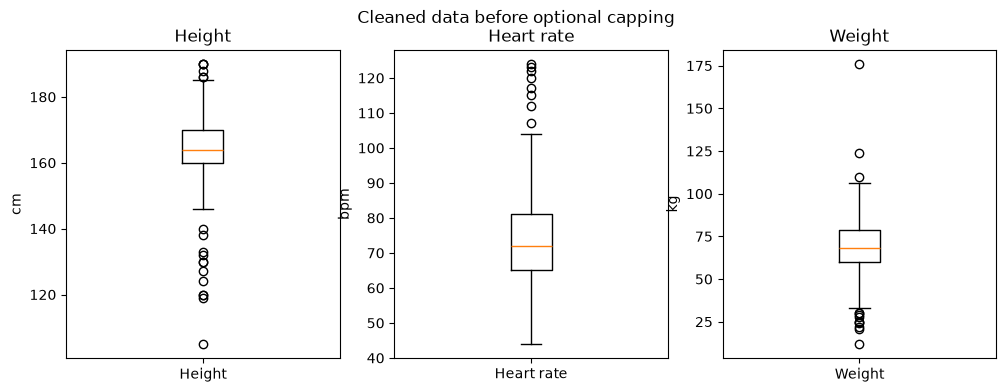

In [136]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].boxplot(df_etl_clean["height"].dropna(), tick_labels=["Height"])
axes[0].set_title("Height"); axes[0].set_ylabel("cm")
axes[1].boxplot(df_etl_clean["heart_rate"].dropna(), tick_labels=["Heart rate"])
axes[1].set_title("Heart rate"); axes[1].set_ylabel("bpm")
axes[2].boxplot(df_etl_clean["weight"].dropna(), tick_labels=["Weight"])
axes[2].set_title("Weight"); axes[2].set_ylabel("kg")
plt.suptitle("Cleaned data before optional capping")
plt.show()


In [137]:
df_sensitivity = df_etl_clean.copy(deep=True)

df_sensitivity["height_capped"] = df_sensitivity["height"].clip(
    lower=df_sensitivity["height"].quantile(0.01)
)

df_sensitivity["heart_rate_capped"] = df_sensitivity["heart_rate"].clip(
    lower=df_sensitivity["heart_rate"].quantile(0.01),
    upper=df_sensitivity["heart_rate"].quantile(0.99)
)

df_sensitivity["weight_capped"] = df_sensitivity["weight"].clip(
    upper=df_sensitivity["weight"].quantile(0.99)
)


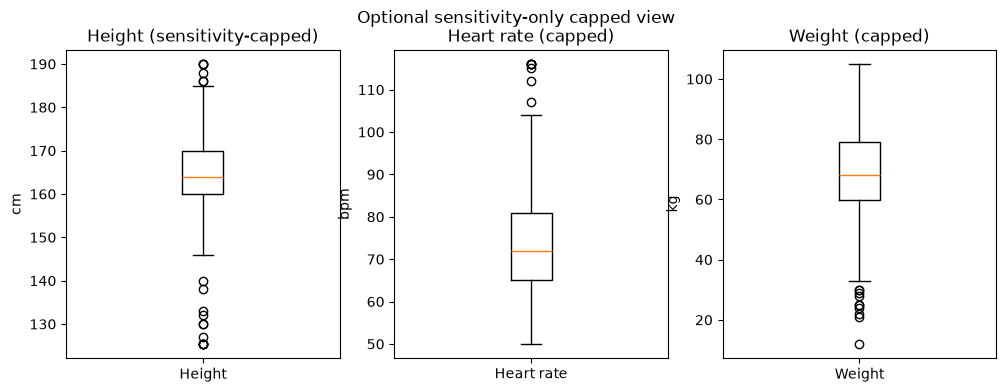

In [138]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].boxplot(df_sensitivity["height_capped"].dropna(), tick_labels=["Height"])
axes[0].set_title("Height (sensitivity-capped)"); axes[0].set_ylabel("cm")
axes[1].boxplot(df_sensitivity["heart_rate_capped"].dropna(), tick_labels=["Heart rate"])
axes[1].set_title("Heart rate (capped)"); axes[1].set_ylabel("bpm")
axes[2].boxplot(df_sensitivity["weight_capped"].dropna(), tick_labels=["Weight"])
axes[2].set_title("Weight (capped)"); axes[2].set_ylabel("kg")
plt.suptitle("Optional sensitivity-only capped view")
plt.show()


sex
0    0.580000
1    0.354839
Name: arrhythmia_present, dtype: float64


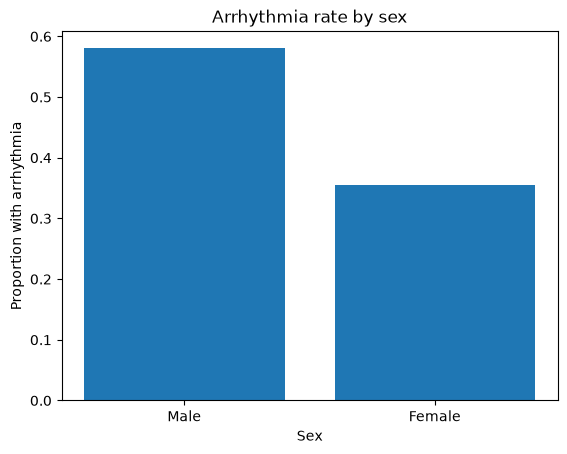

In [139]:
rate = df_etl_clean.groupby("sex", observed=False)["arrhythmia_present"].mean()
print(rate)

sex_labels = {0: "Male", 1: "Female"}
labels = [sex_labels[int(value)] for value in rate.index]

plt.bar(labels, rate.values)
plt.xlabel("Sex")
plt.ylabel("Proportion with arrhythmia")
plt.title("Arrhythmia rate by sex")
plt.show()          # Figure 13 is what you'll see


               age  height  weight  qrs_duration  pr_interval  qt_interval  \
age           1.00    0.22    0.35         -0.01         0.03         0.14   
height        0.22    1.00    0.58          0.04         0.07         0.02   
weight        0.35    0.58    1.00          0.09         0.12         0.04   
qrs_duration -0.01    0.04    0.09          1.00         0.02         0.22   
pr_interval   0.03    0.07    0.12          0.02         1.00         0.07   
qt_interval   0.14    0.02    0.04          0.22         0.07         1.00   
heart_rate   -0.12   -0.18   -0.08          0.01        -0.04        -0.62   

              heart_rate  
age                -0.12  
height             -0.18  
weight             -0.08  
qrs_duration        0.01  
pr_interval        -0.04  
qt_interval        -0.62  
heart_rate          1.00  
Strongest absolute correlation: ('qt_interval', 'heart_rate') -0.62


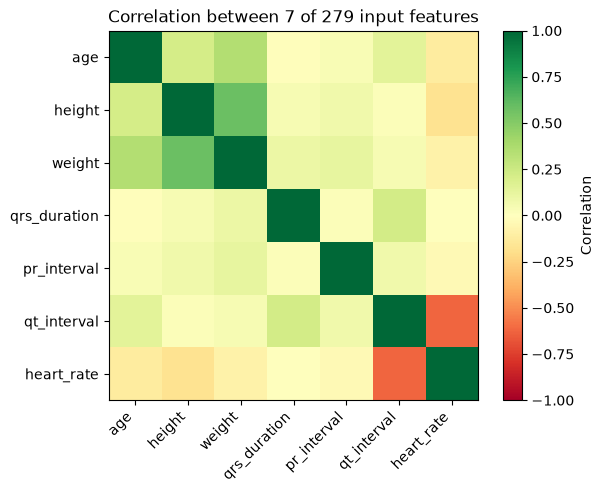

In [140]:
import numpy as np

num_cols = ["age", "height", "weight", "qrs_duration", "pr_interval", "qt_interval", "heart_rate"]
corr_matrix = df_etl_clean[num_cols].corr()
print(corr_matrix.round(2))

# Find the strongest non-diagonal linear association
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
strongest_pair = upper_triangle.abs().stack().idxmax()
print(
    "Strongest absolute correlation:",
    strongest_pair,
    round(corr_matrix.loc[strongest_pair[0], strongest_pair[1]], 2)
)

plt.imshow(corr_matrix, cmap="RdYlGn", vmin=-1, vmax=1)
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha="right")
plt.yticks(range(len(num_cols)), num_cols)
plt.colorbar(label="Correlation")
plt.title("Correlation between 7 of 279 input features")
plt.show()          # Figure 14 is what you'll see


Patients per class:
class
1     244
2      44
3      15
4      15
5      10
6      25
7       3
8       2
9       9
10     50
14      4
15      5
16     22
Name: count, dtype: int64
Mean profile per class:
       p_interval  qrs_duration  pr_interval  qt_interval  t_interval  \
class                                                                   
1            92.2          84.3        157.2        367.2       163.0   
2            87.5          89.8        153.0        369.6       190.7   
3            98.4          93.3        163.2        355.5       201.8   
4            94.0          89.9        160.4        352.1       170.0   
5            88.2          89.6        164.5        311.9       156.8   
6            80.0          83.2        158.0        393.2       152.9   
7            98.0          96.3        190.7        365.3       185.3   
8           101.5          98.5        183.0        368.0       185.0   
9            90.3         154.4        158.4        439.4       

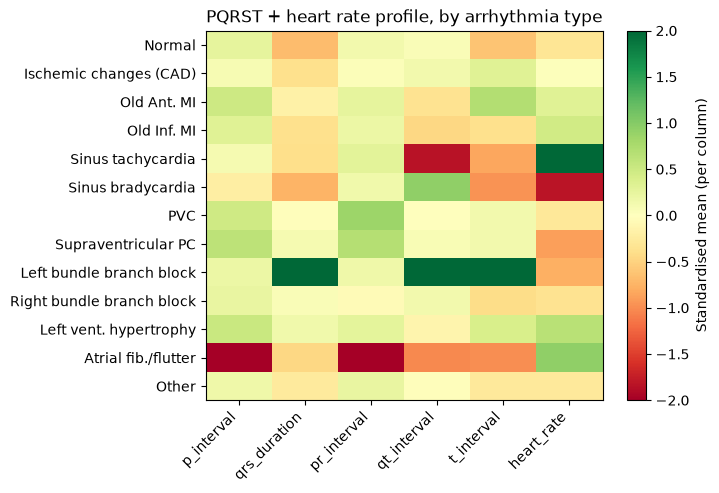

In [141]:
class_names = {
    1: "Normal", 2: "Ischemic changes (CAD)", 3: "Old Ant. MI", 4: "Old Inf. MI",
    5: "Sinus tachycardia", 6: "Sinus bradycardia", 7: "PVC", 8: "Supraventricular PC",
    9: "Left bundle branch block", 10: "Right bundle branch block",
    11: "1st degree AV block", 12: "2nd degree AV block", 13: "3rd degree AV block",
    14: "Left vent. hypertrophy", 15: "Atrial fib./flutter", 16: "Other",
}

pqrst_cols = ["p_interval", "qrs_duration", "pr_interval", "qt_interval", "t_interval", "heart_rate"]
class_counts = df_etl_clean["class"].value_counts().sort_index()
print("Patients per class:")
print(class_counts)

profile = df_etl_clean.groupby("class")[pqrst_cols].mean()
print("Mean profile per class:")
print(profile.round(1))
# standardise each column so differing scales (ms vs bpm) do not dominate the color map
profile_z = (profile - profile.mean()) / profile.std()
row_labels = [class_names[int(c)] for c in profile_z.index]

plt.imshow(profile_z.values, cmap="RdYlGn", vmin=-2, vmax=2, aspect="auto")
plt.xticks(range(len(pqrst_cols)), pqrst_cols, rotation=45, ha="right")
plt.yticks(range(len(profile_z)), row_labels)
plt.colorbar(label="Standardised mean (per column)")
plt.title("PQRST + heart rate profile, by arrhythmia type")
plt.show()



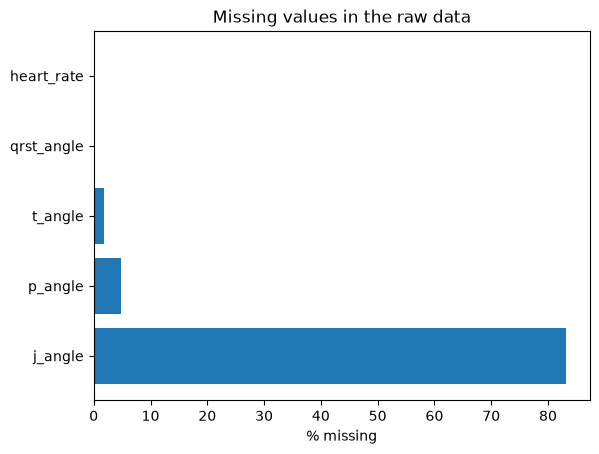

In [142]:
miss = df_original.isna().mean().sort_values(ascending=False)
miss = miss[miss > 0] * 100
plt.barh(miss.index.astype(str), miss.values)
plt.xlabel("% missing")
plt.title("Missing values in the raw data")
plt.show()


Mean heart rate by class:
class
6      53.920000
8      66.000000
9      67.444444
10     72.820000
1      73.213115
7      73.666667
16     73.863636
2      77.681818
3      81.333333
4      83.133333
14     85.500000
15     89.200000
5     106.900000
Name: heart_rate, dtype: float64


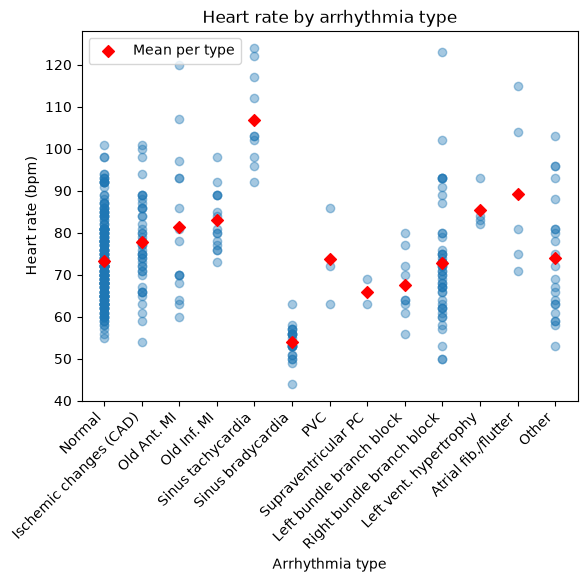

In [143]:
order = sorted(df_etl_clean["class"].unique())
x_pos = df_etl_clean["class"].map({c: i for i, c in enumerate(order)})
plt.scatter(x_pos, df_etl_clean["heart_rate"], alpha=0.4)
means = df_etl_clean.groupby("class")["heart_rate"].mean()
print("Mean heart rate by class:")
print(means.sort_values())
plt.scatter(range(len(order)), [means[c] for c in order], color="red", marker="D", label="Mean per type")
plt.xticks(range(len(order)), [class_names[c] for c in order], rotation=45, ha="right")
plt.xlabel("Arrhythmia type"); plt.ylabel("Heart rate (bpm)")
plt.title("Heart rate by arrhythmia type")
plt.legend()
plt.show()


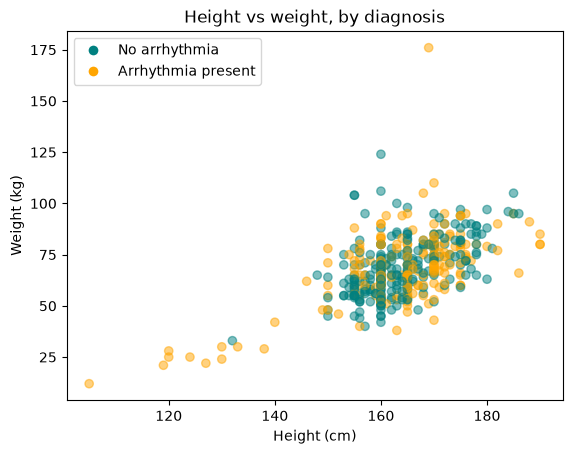

In [144]:
colors = df_etl_clean["arrhythmia_present"].map({True: "orange", False: "teal"})
plt.scatter(df_etl_clean["height"], df_etl_clean["weight"], c=colors, alpha=0.5)
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.title("Height vs weight, by diagnosis")

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="teal", markersize=8, label="No arrhythmia"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="orange", markersize=8, label="Arrhythmia present"),
]
plt.legend(handles=legend_handles)
plt.show()


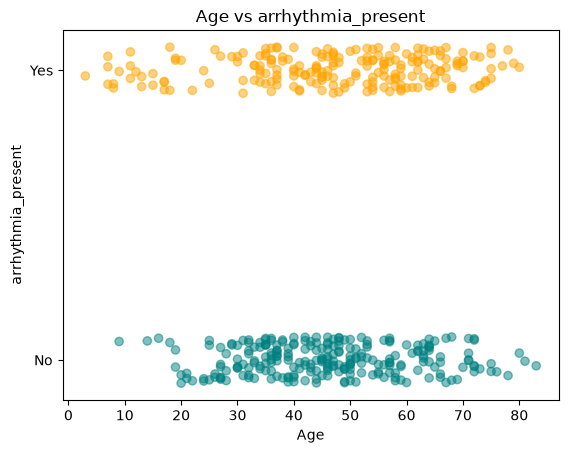

In [145]:
import numpy as np
jitter = df_etl_clean["arrhythmia_present"].astype(int) + np.random.uniform(-0.08, 0.08, len(df_etl_clean))
colors = df_etl_clean["arrhythmia_present"].map({True: "orange", False: "teal"})
plt.scatter(df_etl_clean["age"], jitter, c=colors, alpha=0.5)
plt.yticks([0, 1], ["No", "Yes"])
plt.xlabel("Age")
plt.ylabel("arrhythmia_present")
plt.title("Age vs arrhythmia_present")
plt.show()          # y-axis labels (No/Yes) already identify the two colours here


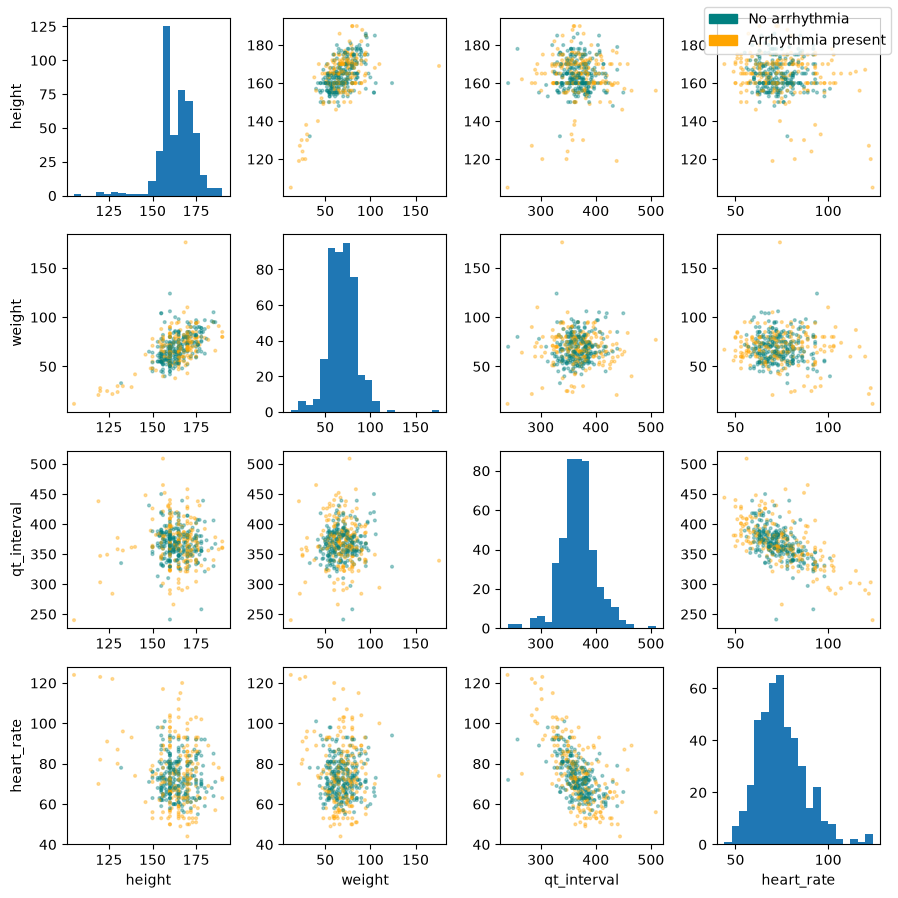

In [146]:
colors = df_etl_clean["arrhythmia_present"].map({True: "orange", False: "teal"})
cols = ["height", "weight", "qt_interval", "heart_rate"]
fig, axes = plt.subplots(4, 4, figsize=(9, 9))
for i, c1 in enumerate(cols):
    for j, c2 in enumerate(cols):
        ax = axes[i, j]
        if i == j:
            ax.hist(df_etl_clean[c1].dropna(), bins=20)
        else:
            ax.scatter(df_etl_clean[c2], df_etl_clean[c1], s=4, alpha=0.35, c=colors)
        if i == 3:
            ax.set_xlabel(c2)
        if j == 0:
            ax.set_ylabel(c1)

plt.tight_layout()

from matplotlib.patches import Patch
fig.legend(handles=[
    Patch(color="teal", label="No arrhythmia"),
    Patch(color="orange", label="Arrhythmia present"),
], loc="upper right")
plt.show()


In [147]:
%pip install scipy
from scipy import stats

a = df_etl_clean.loc[df_etl_clean["arrhythmia_present"], "heart_rate"]
b = df_etl_clean.loc[~df_etl_clean["arrhythmia_present"], "heart_rate"]

t, p = stats.ttest_ind(a, b, equal_var=False)
print("Mean with arrhythmia:", a.mean())
print("Mean without arrhythmia:", b.mean())
print(f"t = {t:.2f}, p = {p:.4f}")

if p < 0.05:
    print("Reject H0: the mean heart rates differ significantly.")
else:
    print("Fail to reject H0: no significant mean difference was detected.")


Note: you may need to restart the kernel to use updated packages.
Mean with arrhythmia: 75.07843137254902
Mean without arrhythmia: 73.21311475409836
t = 1.46, p = 0.1441
Fail to reject H0: no significant mean difference was detected.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [148]:
table = pd.crosstab(
    df_etl_clean["sex"],
    df_etl_clean["arrhythmia_present"]
)
print(table)

chi2, p, dof, expected = stats.chi2_contingency(table)
print(f"chi2 = {chi2:.2f}, p = {p:.6f}")

if p < 0.05:
    print("Reject H0: sex and diagnosis are associated in this sample.")
else:
    print("Fail to reject H0: no significant association was detected.")


arrhythmia_present  False  True 
sex                             
0                      84    116
1                     160     88
chi2 = 21.73, p = 0.000003
Reject H0: sex and diagnosis are associated in this sample.


In [149]:
print(df_etl_clean.shape)
 


(448, 281)


In [150]:

clinical_cols = ["age", "sex", "height", "weight", "qrs_duration",
    "pr_interval", "qt_interval", "t_interval", "p_interval",
    "qrs_angle", "t_angle", "p_angle", "qrst_angle", "bmi"]
 
correlations = df_etl_clean[clinical_cols + ["heart_rate"]].corr()["heart_rate"]
print(correlations.abs().sort_values(ascending=False))


heart_rate      1.000000
qt_interval     0.617472
height          0.176618
p_angle         0.125856
age             0.122496
weight          0.082403
sex             0.080319
t_angle         0.074463
p_interval      0.063117
t_interval      0.043729
qrs_angle       0.043620
bmi             0.038837
qrst_angle      0.038037
pr_interval     0.037148
qrs_duration    0.005194
Name: heart_rate, dtype: float64


In [151]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
 
# df_etl_clean is still the same object from Lecture 2–3
X = df_etl_clean[["qt_interval"]]
y = df_etl_clean["heart_rate"]
 
print("X:", X.shape, " y:", y.shape)


X: (448, 1)  y: (448,)


In [152]:
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
 
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (313, 1)  Test: (135, 1)


In [153]:
model = LinearRegression()
model.fit(X_train, y_train)
 
print("Model trained on", len(X_train), "patients")


Model trained on 313 patients


In [154]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)


Coefficients: [-0.24785936]
Intercept: 165.1525239758605


In [155]:
predictions = model.predict(X_test)
 
comparison = pd.DataFrame({
    "actual": y_test,
    "predicted": predictions
})
print(comparison.head())


     actual  predicted
285    72.0  70.470248
296    73.0  70.470248
117    93.0  77.658169
346    63.0  72.453123
70     69.0  76.914591


In [156]:
r2 = r2_score(y_test, predictions)
print("R²:", round(r2, 2))


R²: 0.34


In [157]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
 
# still the same df_etl_clean, same session
X = df_etl_clean[["qrs_duration", "heart_rate", "age"]]
y = df_etl_clean["arrhythmia_present"]
 
print(X.shape)
print(y.value_counts())

(448, 3)
arrhythmia_present
False    244
True     204
Name: count, dtype: int64


In [158]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
 
print("Train arrhythmia rate:", round(y_train.mean(), 2))
print("Test arrhythmia rate:", round(y_test.mean(), 2))


Train arrhythmia rate: 0.46
Test arrhythmia rate: 0.45


In [159]:

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
 
probabilities = model.predict_proba(X_test)
print(probabilities[:5])   # first 5 rows, illustrative

[[0.31632703 0.68367297]
 [0.55784969 0.44215031]
 [0.59719344 0.40280656]
 [0.3761771  0.6238229 ]
 [0.67144133 0.32855867]]


In [162]:
predictions = model.predict(X_test)
 
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", round(accuracy, 2))


Accuracy: 0.73


In [163]:
baseline_guess = y_train.value_counts().idxmax()
baseline_accuracy = (y_test == baseline_guess).mean()
 
print("Baseline:", round(baseline_accuracy, 2))


Baseline: 0.55


In [164]:
cm = confusion_matrix(y_test, predictions)
print(cm)


[[65  9]
 [27 34]]


In [165]:
from sklearn.preprocessing import StandardScaler
 
# same df_etl_clean, no relabelling needed
features = ["heart_rate", "qrs_duration", "age"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_etl_clean[features])
 
print(X_scaled[:3])   # first 3 rows, illustrative


[[-0.86224009  0.13199286  1.75679487]
 [-1.64166615 -0.51710486  0.57514035]
 [ 0.07307119  3.18275215  0.45075567]]


In [166]:
from sklearn.cluster import KMeans
 
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df_etl_clean["cluster"] = kmeans.fit_predict(X_scaled)
 
print(df_etl_clean["cluster"].value_counts())


cluster
1    273
0    175
Name: count, dtype: int64


In [167]:
print(pd.crosstab(
    df_etl_clean["cluster"],
    df_etl_clean["arrhythmia_present"]
))


arrhythmia_present  False  True 
cluster                         
0                      94     81
1                     150    123
